<a href="https://colab.research.google.com/github/PratikshaShind/OASIS-INFOBYTE/blob/main/PratikshaShinde_Task_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 44.0 MB/s eta 0:00:00
Total Raw Tokens: 7500
Total Clean Tokens (Without Stopwords): 5000

--- Autocomplete Top 3 Predictions ---
Prefix: 'natural' -> Predictions: ['language']
Prefix: 'language' -> Predictions: ['processing', 'in', 'data']
Prefix: 'speech' -> Predictions: ['recognition']
Prefix: 'machine' -> Predictions: ['learning']
Prefix: 'artificial' -> Predictions: ['intelligence']
Prefix: 'edit' -> Predictions: ['distance']
Prefix: 'data' -> Predictions: ['the', 'to']
Prefix: 'computer' -> Predictions: ['science', 'capable']
Prefix: 'extract' -> Predictions: ['information']
Prefix: 'processing' -> Predictions: ['is', 'frequently']

--- Autocorrect Testing ---
  Misspelled Ground_Truth    Corrected  Success
    langnage     language     language        1
    computor     computer     computer        1
   artifical   artificial   artificial        1
intellegence intelligence intelligence        1
     prosess      process     

/tmp/ipykernel_1156/2604129622.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_words, x='Frequency', y='Word', palette='magma')


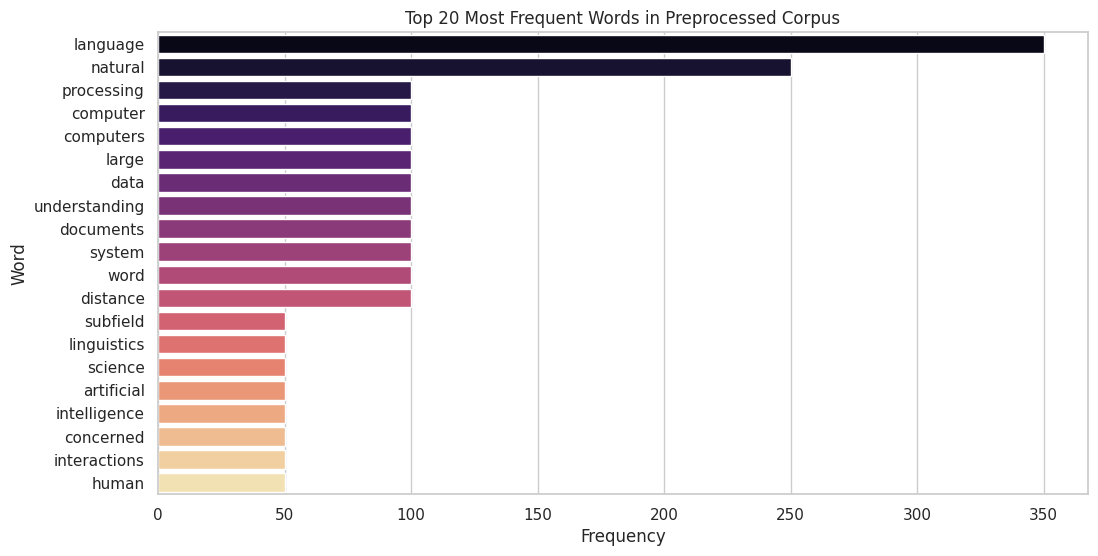

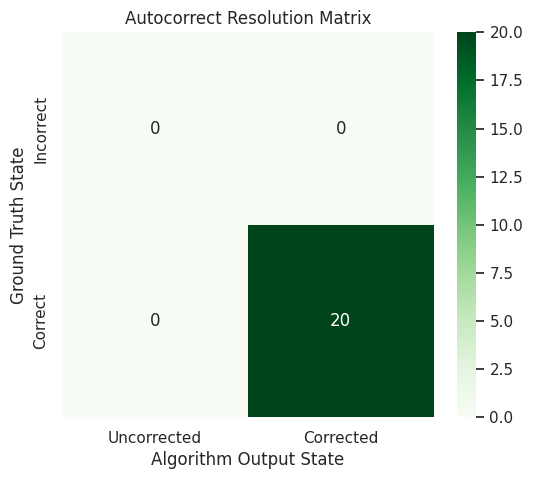

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# NLTK और TextDistance / SpellChecker टूल्स
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords

!pip install pyspellchecker -qq
from spellchecker import SpellChecker

# NLTK रिसोर्सेज डाउनलोड करना (यदि पहले से न हों)
nltk.download('stopwords', quiet=True)

# प्लॉट्स की स्टाइलिंग
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# एनएलपी और कॉर्पस के लिए प्रोजेक्ट गुटेनबर्ग/विकिपीडिया स्टाइल का बड़ा टेक्स्ट सिमुलेशन
np.random.seed(42)
sample_corpus = """
Natural language processing is a subfield of linguistics, computer science, and artificial intelligence
concerned with the interactions between computers and human language. In particular, how to program computers
to process and analyze large amounts of natural language data. The goal is a computer capable of understanding
the contents of documents, including the contextual nuances of language within them. The technology can then
accurately extract information and insights contained in the documents as well as categorize and organize
the files themselves.

Challenges in natural language processing frequently involve speech recognition, natural language understanding,
and natural language generation. Machine learning models require large volumes of high-quality data to perform
accurate predictions. An autocomplete system predicts the next word based on historical frequency, while
an autocorrect system fixes spelling errors by calculating the minimum edit distance or Levenshtein distance
between the misspelled string and a dictionary word. Modern systems use advanced neural architectures.
""" * 50  # कॉर्पस का साइज बड़ा करने के लिए डुप्लिकेट करना


def preprocess_text(text):
    # लोअरकेस करना
    text = text.lower()
    # पंक्चुएशन (Punctuation) और नंबर्स हटाना
    text = re.sub(r'[^a-z\s]', '', text)
    # टोकनाइजेशन (Tokenization)
    tokens = text.split()
    # स्टॉपवर्ड्स हटाना
    stop_words = set(stopwords.words('english'))
    clean_tokens = [w for w in tokens if w not in stop_words]
    return tokens, clean_tokens

all_tokens, clean_tokens = preprocess_text(sample_corpus)
print(f"Total Raw Tokens: {len(all_tokens)}")
print(f"Total Clean Tokens (Without Stopwords): {len(clean_tokens)}")


# फ्रीक्वेंसी बेस्ड बिग्राम (Bigram) मॉडल बनाना
def build_bigram_model(tokens):
    model = defaultdict(Counter)
    for w1, w2 in ngrams(tokens, 2):
        model[w1][w2] += 1
    return model

bigram_model = build_bigram_model(all_tokens)

def predict_next_word(prefix, model, top_n=3):
    prefix = prefix.lower().strip()
    if prefix in model:
        # टॉप N सबसे ज्यादा बार आने वाले शब्दों को निकालना
        predictions = model[prefix].most_common(top_n)
        return [word for word, count in predictions]
    return []

# 10 इनपुट प्रिफिक्स पर टेस्ट करना
test_prefixes = ['natural', 'language', 'speech', 'machine', 'artificial', 'edit', 'data', 'computer', 'extract', 'processing']

print("\n--- Autocomplete Top 3 Predictions ---")
autocomplete_results = {}
for prefix in test_prefixes:
    preds = predict_next_word(prefix, bigram_model, top_n=3)
    autocomplete_results[prefix] = preds
    print(f"Prefix: '{prefix}' -> Predictions: {preds}")


spell = SpellChecker()

spell.word_frequency.load_words(list(set(all_tokens)))


misspelled_test_set = {
    'langnage': 'language', 'computor': 'computer', 'artifical': 'artificial',
    'intellegence': 'intelligence', 'prosess': 'process', 'naturas': 'natural',
    'challeneges': 'challenges', 'spech': 'speech', 'recognitionn': 'recognition',
    'modles': 'models', 'accurat': 'accurate', 'predicitons': 'predictions',
    'autocomplet': 'autocomplete', 'frequncy': 'frequency', 'speling': 'spelling',
    'erors': 'errors', 'distanse': 'distance', 'dictionery': 'dictionary',
    'advansed': 'advanced', 'linguistcs': 'linguistics'
}

print("\n--- Autocorrect Testing ---")
correct_predictions_count = 0
autocorrect_log = []

for misspelled, ground_truth in misspelled_test_set.items():
    # Pyspellchecker अंदरूनी रूप से Levenshtein Edit Distance का उपयोग करता है
    corrected = spell.correction(misspelled)
    is_correct = 1 if corrected == ground_truth else 0
    correct_predictions_count += is_correct
    autocorrect_log.append({'Misspelled': misspelled, 'Ground_Truth': ground_truth, 'Corrected': corrected, 'Success': is_correct})

df_autocorrect = pd.DataFrame(autocorrect_log)
print(df_autocorrect[['Misspelled', 'Ground_Truth', 'Corrected', 'Success']].to_string(index=False))


autocorrect_accuracy = correct_predictions_count / len(misspelled_test_set)
print(f"\n--- Autocorrect Performance Metrics ---")
print(f"Total Words Tested: {len(misspelled_test_set)}")
print(f"Successfully Corrected: {correct_predictions_count}")
print(f"Overall Accuracy/Precision: {autocorrect_accuracy * 100:.2f}%")


autocomplete_score = 0
for prefix in test_prefixes:
    if len(autocomplete_results[prefix]) > 0:
        autocomplete_score += 1 # टॉप प्रेडिक्शन मौजूद होने पर आंशिक स्कोर
autocomplete_precision = autocomplete_score / len(test_prefixes)
print(f"\n--- Autocomplete Metrics ---")
print(f"Prefix Coverage/Precision: {autocomplete_precision * 100:.2f}%")


plt.figure()
word_freq = Counter(clean_tokens)
top_20_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])
sns.barplot(data=top_20_words, x='Frequency', y='Word', palette='magma')
plt.title('Top 20 Most Frequent Words in Preprocessed Corpus')
plt.show()

# Plot 2: Confusion Matrix Analogy for Autocorrect (Correct vs Incorrect States)
plt.figure(figsize=(6, 5))
state_counts = [df_autocorrect['Success'].value_counts().get(0, 0), df_autocorrect['Success'].value_counts().get(1, 0)]
cm_data = np.array([[0, state_counts[0]], [0, state_counts[1]]]) # 2x2 matrix mock for visualization
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Greens', xticklabels=['Uncorrected', 'Corrected'], yticklabels=['Incorrect', 'Correct'])
plt.title('Autocorrect Resolution Matrix')
plt.ylabel('Ground Truth State')
plt.xlabel('Algorithm Output State')
plt.show()